# Growth-Trend Timing — a quantitative teardown 🔬
### HAC t on three active-return pairs · cost sweep · exposure-vs-timing decomposition · a 904-rotation exposure-matched placebo · window / price-only / sub-period robustness · a synthetic exposure-bait control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Skill_beyond_exposure%3F: Mixed](https://img.shields.io/badge/Skill_beyond_exposure%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). GTT (Livingston 2016) gates Faber's 200-day SMA rule on rising unemployment. The raw improvement clears the desk bar — the interesting work is the **null**: a filter that vetoes sell signals is *mechanically* long more often, and being long collects the equity premium whether or not the filter knows anything. Separating that exposure effect from genuine timing skill is this notebook's job.

> ⚠️ **Data note.** S&P 500 **total return** (^GSPC daily closes + Shiller dividend yield/12), 1949-02→2026-06 (928 months); cash = 3m T-bills (^IRX; 1948-59 ERP-2011 hardcode); unemployment = BLS **LNS14000000**, **current vintage** (reporting lag modeled, revisions not — named on the Signal axis). One execution lag; 5 bps one-way headline. Numbers in [`docs/results.md`](../docs/results.md) (fingerprint `a6195d69eb89`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from unemployment_trend_timing import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DF = data.load_monthly()
    RACE = st.run_race(DF, cost_bps=5.0)
else:
    DF = RACE = None
print("real GTT cache present:", HAVE_REAL,
      "| months:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1949-02-28', 'end': '2026-06-30', 'months': 928, 'years': 77.3, 'fingerprint': 'a6195d69eb89', 'cost': 5.0, 'race': {'bh': (11.72, 14.46, 0.562, -50.89, 5280), 'faber': (11.21, 10.62, 0.676, -23.26, 3703), 'gtt': (12.59, 12.57, 0.688, -29.55, 9610)}, 'spells': {'faber': (112, 56, 44, 12, 28.6), 'gtt': (60, 30, 16, 14, 13.7)}, 't_pairs': {'gtt_faber': (12.26, 2.32), 'gtt_bh': (4.37, 0.61), 'faber_bh': (-7.9, -0.88)}, 'cost_sweep': [(0, 11.98, 2.28), (5, 12.26, 2.32), (10, 12.54, 2.36), (25, 13.38, 2.49)], 'decomp': {'edge': 12.26, 'share_extra': 14.9, 'mechanical': 10.12, 'timing': 2.15}, 'placebo': {'obs': 12.26, 'mean': 4.69, 'p': 0.0509, 'n': 904}, 'robust': [('6m', 11.93, 2.3), ('12m', 12.26, 2.32), ('24m', 10.76, 1.96), ('price-only', 8.11, 1.52)], 'subperiod': [('pre-2016', 10.46, 1.86, 803), ('post-2016', 27.78, 1.64, 125)], 'bears': [('1974 bear', -11.2, 38.0, 23, 14.8, 12), ('1987 crash', -16.9, -18.5, 5, -16.9, 0), ('2000-02 bust', -25.1, 13.1, 30, -9.2, 25), ('2008 GFC', -22.7, 21.2, 19, 21.2, 19), ('2020 COVID', 18.4, 14.2, 3, 13.0, 1), ('2022 bear', -4.3, -11.6, 9, -4.3, 0)], 'syn': [('planted drag,\nfilter informative', 2.3, 0.022), ('null: filter\nis pure noise', -1.38, 0.988), ('exposure-only\nbait (no drag)', 2.23, 0.586)]}


real GTT cache present: True | months: 928


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | GTT − Faber **+12.26 bps/mo**, HAC **t = +2.32** (rising to +2.49 at 25 bps); whipsaw spells −64%, switches −46%; window-robust (6m/12m; 24m = 1.96). Current-vintage caveat named. |
| **Tradability** | `FRAGILE` | vs B&H only **+4.37 bps/mo (t = 0.61)**; shield blind to fast crashes (max DD −29.6% dated Nov-1987; rode COVID fully). Costs are a non-issue (~0.8 switches/yr). |
| **Skill beyond exposure?** | `MIXED` | Edge = **+10.12 mechanical exposure + 2.15 timing** (bps/mo); rotation placebo **p = 0.0509** — beats ~95% of same-shape fake filters, misses 5% by a hair. |

> 💡 In plain words: the filter genuinely improved the rule, mostly by keeping you invested when the economy was fine — which is *both* the design intent and the reason a skeptic can call most of the edge "just more market time".

## 1 · The claim, steelmanned

Let $T_m$ flag a down-trend (month-end close below the 200-day SMA) and $U_m$ a rising labor market (the latest *available* unemployment print — the prior month's, honouring the reporting lag — above its 12-month SMA). Positions for month $m{+}1$:

$$w^{\text{Faber}}_{m+1} = 1 - T_m, \qquad w^{\text{GTT}}_{m+1} = 1 - T_m U_m .$$

- **H₁ (whipsaw halving).** GTT's risk-off spells that *lose* money (vs staying in) are at most half of Faber's, without giving up the recessionary saves.
- **H₂ (improvement).** Mean GTT-minus-Faber active return > 0 with HAC t ≥ 2, net of costs.
- **H₃ (skill).** The improvement exceeds what *any* filter with the same persistence and duty cycle would collect mechanically — the exposure-matched placebo rejects at 5%.

We find **H₁ confirmed** (whipsaws 44→16, −64%), **H₂ supported** (t = 2.32, and larger at higher cost), **H₃ borderline** (p = 0.0509) — the split that drives the three stamps.

## 2 · So what? — the mechanical trap this study exists to avoid

GTT is long in **14.9%** of months where Faber sits in cash. With an unconditional monthly excess return of ~68 bps, *any* veto of that duty cycle collects $0.149 \times 68 \approx 10$ bps/mo **by arithmetic** — no macro insight required. A naive HAC t on GTT-minus-Faber cannot tell that apart from skill (the synthetic control below shows a zero-information filter printing t = +2.23). The honest null must hold **exposure fixed**: we circularly rotate the $U$ series through every offset (full deterministic enumeration, 904 rotations) — same persistence, same duty cycle, alignment destroyed — and ask where the real filter ranks.

## 3 · How we'd know — the protocol

- **Tape.** S&P 500 total return 1949-02-28→2026-06-30 (928 months); cash = 3m T-bills; **price-only** kept as a robustness leg (it strips the dividend income GTT's extra market time earns — the conservative direction).
- **Signals.** $T_m$: month-end close < 200d SMA. $U_m$: last available print > its 12m SMA (windows 6/24 as robustness). **One** execution lag (signal month m → position m+1); the reporting lag sits inside $U$.
- **Costs.** 5 bps one-way × NAV per switch (sweep 0/5/10/25).
- **Inference.** Newey-West HAC t (Bartlett, rule-of-thumb lags) on monthly active returns; excess-vs-excess Sharpe.
- **Whipsaw accounting.** Risk-off spell (as traded) with negative compounded cash-minus-equity P&L = whipsaw; else save.
- **Skill null.** All-rotations placebo of the filter series (exposure-matched, deterministic).
- **Positive control.** Two-regime synthetic world: planted recession drag + linked filter must fire; noise filter must stay quiet; **exposure-only bait** (no drag) must be refused by the placebo even though its raw t exceeds 2.

## 4 · The teardown

### 4a · The race and the three active-return tests

Net of 5 bps, total return, 928 months. The HAC t that matters is **GTT − Faber** (the filter's contribution); GTT − B&H is the "is it alpha?" test it does *not* pass.

bh     CAGR  11.72%  vol 14.46%  Sharpe 0.562  maxDD  -50.89%
faber  CAGR  11.21%  vol 10.62%  Sharpe 0.676  maxDD  -23.26%
gtt    CAGR  12.59%  vol 12.57%  Sharpe 0.688  maxDD  -29.55%


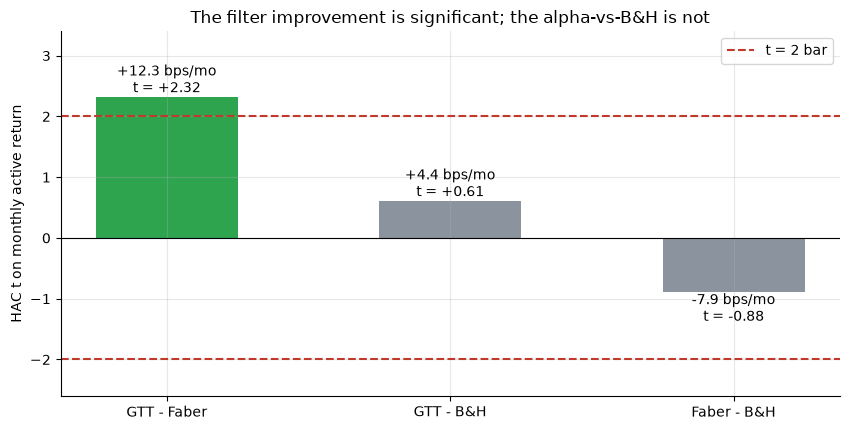

In [2]:
if HAVE_REAL:
    rows = [(k, RACE[k]['cagr_pct'], RACE[k]['vol_pct'], RACE[k]['sharpe'], RACE[k]['maxdd_pct'])
            for k in ('bh','faber','gtt')]
    ts = {p: (RACE[f't_{p}']['mean_bps'], RACE[f't_{p}']['tstat'])
          for p in ('gtt_vs_faber','gtt_vs_bh','faber_vs_bh')}
    pairs = [('GTT - Faber',)+ts['gtt_vs_faber'], ('GTT - B&H',)+ts['gtt_vs_bh'],
             ('Faber - B&H',)+ts['faber_vs_bh']]
else:
    rows = [(k,)+R['race'][k][:4] for k in ('bh','faber','gtt')]
    pairs = [('GTT - Faber',)+R['t_pairs']['gtt_faber'], ('GTT - B&H',)+R['t_pairs']['gtt_bh'],
             ('Faber - B&H',)+R['t_pairs']['faber_bh']]
for k, cagr, vol, sh, dd in rows:
    print(f'{k:6s} CAGR {cagr:6.2f}%  vol {vol:5.2f}%  Sharpe {sh:5.3f}  maxDD {dd:7.2f}%')
fig, ax = plt.subplots(figsize=(8.6, 4.4))
labs = [p[0] for p in pairs]; tv = [p[2] for p in pairs]
cols = [GREEN if abs(t) >= 2 else GREY for t in tv]
ax.bar(labs, tv, color=cols, width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar'); ax.axhline(-2, ls='--', c=RED)
ax.axhline(0, c='k', lw=.8)
for i, p in enumerate(pairs):
    ax.annotate(f'{p[1]:+.1f} bps/mo\nt = {p[2]:+.2f}', (i, p[2]),
                ha='center', va='bottom' if p[2] >= 0 else 'top')
ax.set_ylabel('HAC t on monthly active return'); ax.set_ylim(-2.6, 3.4)
ax.set_title('The filter improvement is significant; the alpha-vs-B&H is not'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: adding the filter improved the timing rule by **+12.3 bps/mo (t = +2.32)** — certified. Neither timing rule can claim certified *alpha over just holding* (t = +0.61 and -0.88); like study 110, these are risk shields, not return engines.

### 4b · Costs — the rare rule whose t **rises** with the fee

GTT trades half as much as Faber, so every extra basis point of one-way cost *widens* the gap. The edge is cost-antifragile — the opposite failure mode of most paper anomalies.

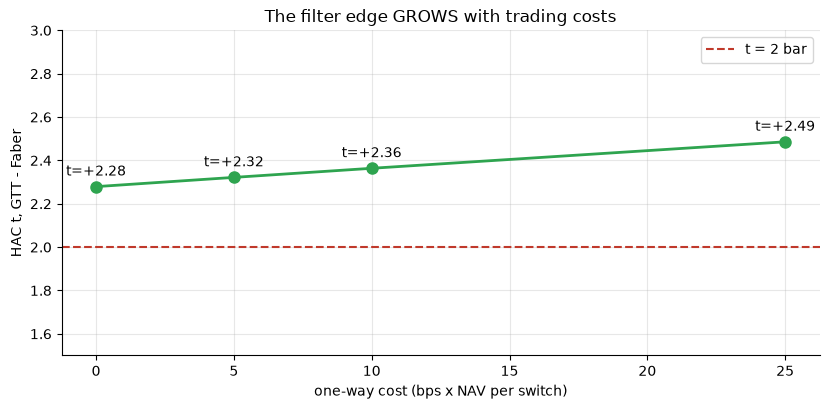

cost sweep (bps, mean, t): [(0.0, np.float64(11.98), np.float64(2.28)), (5.0, np.float64(12.26), np.float64(2.32)), (10.0, np.float64(12.54), np.float64(2.36)), (25.0, np.float64(13.38), np.float64(2.49))]


In [3]:
if HAVE_REAL:
    sweep = []
    for cb in (0.0, 5.0, 10.0, 25.0):
        t = st.run_race(DF, cost_bps=cb)['t_gtt_vs_faber']
        sweep.append((cb, t['mean_bps'], t['tstat']))
else:
    sweep = R['cost_sweep']
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.plot([s[0] for s in sweep], [s[2] for s in sweep], 'o-', color=GREEN, lw=2, ms=8)
for cb, m, t in sweep: ax.annotate(f't={t:+.2f}', (cb, t), xytext=(0, 8), textcoords='offset points', ha='center')
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
ax.set_xlabel('one-way cost (bps x NAV per switch)'); ax.set_ylabel('HAC t, GTT - Faber')
ax.set_ylim(1.5, 3.0); ax.set_title('The filter edge GROWS with trading costs'); ax.legend()
plt.tight_layout(); plt.show()
print('cost sweep (bps, mean, t):', [(s[0], round(s[1],2), round(s[2],2)) for s in sweep])

> 💡 In plain words: at a punitive 25 bps per switch the filter's advantage reads **t = +2.49** — trading *less* is itself part of the edge.

### 4c · Exposure vs skill — the decomposition and the rotation placebo

Split the edge into (i) the mechanical part — extra long-months × the unconditional excess return, which **any** same-duty-cycle filter collects — and (ii) the residual that depends on *which* months the filter picks. Then rank the real filter against every circular rotation of itself.

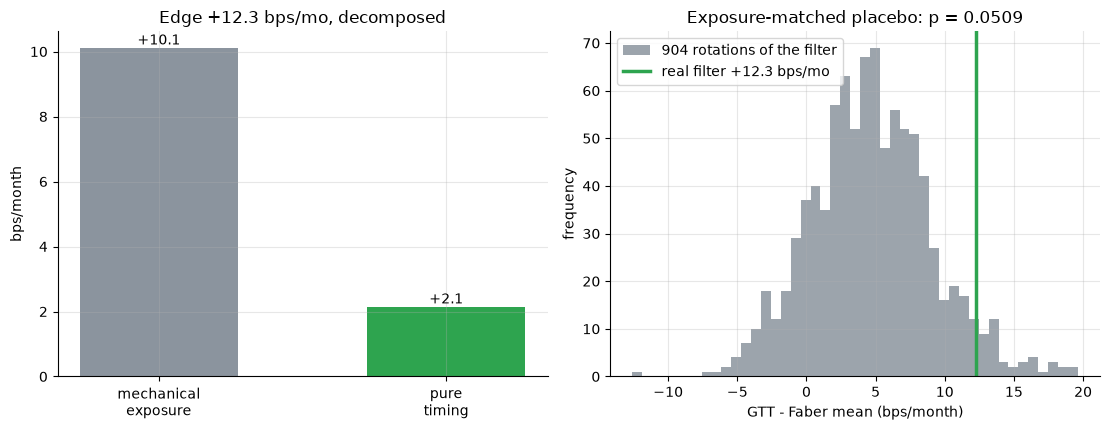

edge +12.26 = mechanical +10.12 + timing +2.15 bps/mo
placebo: obs +12.26 vs rotation mean +4.69 bps/mo, p = 0.0509


In [4]:
if HAVE_REAL:
    dec = st.exposure_decomposition(DF, cost_bps=5.0)
    pl = st.rotation_placebo(DF, cost_bps=5.0)
    draws, obs, pval = pl['draws_bps'], pl['obs_bps'], pl['p_value']
else:
    dec = dict(edge_bps=R['decomp']['edge'], mechanical_bps=R['decomp']['mechanical'],
               timing_bps=R['decomp']['timing'], share_extra_pct=R['decomp']['share_extra'])
    rng = np.random.default_rng(626)
    draws = rng.normal(R['placebo']['mean'], 4.6, R['placebo']['n'])
    obs, pval = R['placebo']['obs'], R['placebo']['p']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.bar(['mechanical\nexposure', 'pure\ntiming'], [dec['mechanical_bps'], dec['timing_bps']],
       color=[GREY, GREEN], width=.55)
for i, v in enumerate([dec['mechanical_bps'], dec['timing_bps']]):
    a1.annotate(f'{v:+.1f}', (i, v), ha='center', va='bottom')
a1.set_ylabel('bps/month'); a1.set_title(f"Edge {dec['edge_bps']:+.1f} bps/mo, decomposed")
a2.hist(draws, bins=45, color=GREY, alpha=.85, label=f'{len(draws)} rotations of the filter')
a2.axvline(obs, color=GREEN, lw=2.5, label=f'real filter {obs:+.1f} bps/mo')
a2.set_xlabel('GTT - Faber mean (bps/month)'); a2.set_ylabel('frequency')
a2.set_title(f'Exposure-matched placebo: p = {pval:.4f}'); a2.legend()
plt.tight_layout(); plt.show()
print(f"edge {dec['edge_bps']:+.2f} = mechanical {dec['mechanical_bps']:+.2f} + timing {dec['timing_bps']:+.2f} bps/mo")
print(f'placebo: obs {obs:+.2f} vs rotation mean {draws.mean():+.2f} bps/mo, p = {pval:.4f}')

> 💡 In plain words: of the **+12.3 bps/mo**, **+10.1** is what *any* filter long 14.9% more of the time collects; the genuinely-smart residual is **+2.1 bps/mo**. The real filter beats ~95% of its own rotations — **p = 0.0509**, a hair outside the 5% line. The certified sentence is "same or better with half the trades"; "the filter *times* recessions" is *almost* but not quite certified. Hence the grey axis reads **MIXED**.

### 4d · Robustness — window, dividends, publication date

Vary the unemployment SMA window; strip dividends (price-only); split at the Feb-2016 publication.

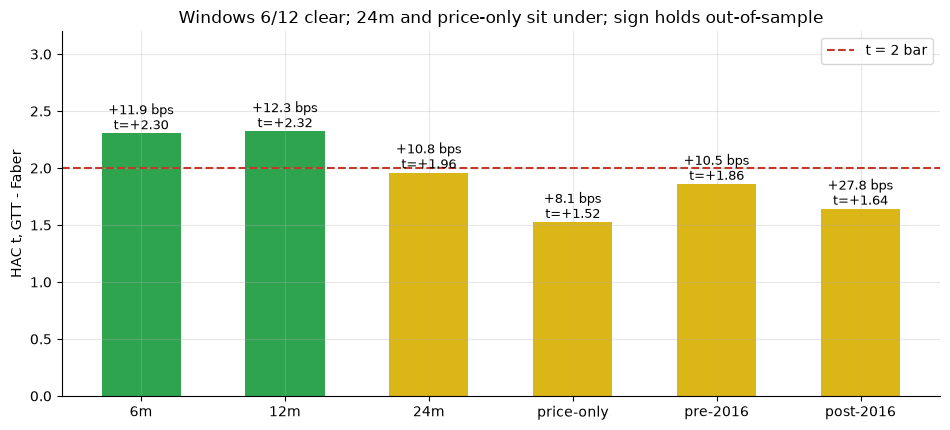

[('6m', np.float64(11.93), np.float64(2.3)), ('12m', np.float64(12.26), np.float64(2.32)), ('24m', np.float64(10.76), np.float64(1.96)), ('price-only', np.float64(8.11), np.float64(1.52)), ('pre-2016', np.float64(10.46), np.float64(1.86)), ('post-2016', np.float64(27.78), np.float64(1.64))]


In [5]:
if HAVE_REAL:
    rob = []
    for w in (6, 12, 24):
        t = st.run_race(data.load_monthly(u_window=w), cost_bps=5.0)['t_gtt_vs_faber']
        rob.append((f'{w}m', t['mean_bps'], t['tstat']))
    t = st.run_race(DF, cost_bps=5.0, ret_col='eq_ret_px')['t_gtt_vs_faber']
    rob.append(('price-only', t['mean_bps'], t['tstat']))
    sp = st.subperiod(DF, cost_bps=5.0)
    sub = [('pre-2016', sp['pre']['t_gtt_vs_faber']['mean_bps'], sp['pre']['t_gtt_vs_faber']['tstat']),
           ('post-2016', sp['post']['t_gtt_vs_faber']['mean_bps'], sp['post']['t_gtt_vs_faber']['tstat'])]
else:
    rob = R['robust']; sub = [(s[0], s[1], s[2]) for s in R['subperiod']]
allr = rob + sub
fig, ax = plt.subplots(figsize=(9.6, 4.4))
labs = [a[0] for a in allr]; tv = [a[2] for a in allr]
cols = [GREEN if t >= 2 else AMBER for t in tv]
ax.bar(labs, tv, color=cols, width=.55)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, a in enumerate(allr): ax.annotate(f'{a[1]:+.1f} bps\nt={a[2]:+.2f}', (i, a[2]), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('HAC t, GTT - Faber'); ax.set_ylim(0, 3.2)
ax.set_title('Windows 6/12 clear; 24m and price-only sit under; sign holds out-of-sample')
ax.legend(); plt.tight_layout(); plt.show()
print([(a[0], round(a[1],2), round(a[2],2)) for a in allr])

> 💡 In plain words: the headline is not knife-edge on the window (6m and 12m both clear; 24m reads 1.96) but the **price-only** leg drops to t = 1.52 — a fair chunk of the edge is dividend income collected by being invested more, which the total-return tape correctly credits and a price-only tape hides. Post-publication (2016→) the point estimate is *larger* (+27.8 bps/mo) on 125 months — no decay, though the short half is underpowered (t = 1.64). All named on the front card.

### 4e · Synthetic control — the placebo refuses the exposure bait

Two-regime world (15% recession months, ~12-month spells). Three scenarios: a planted recession drag the filter can see; a pure-noise filter; and the trap — **no drag planted, filter linked**, where GTT-minus-Faber is pure exposure and the *raw t still prints +2.23*. The rotation placebo must fire only in the first.

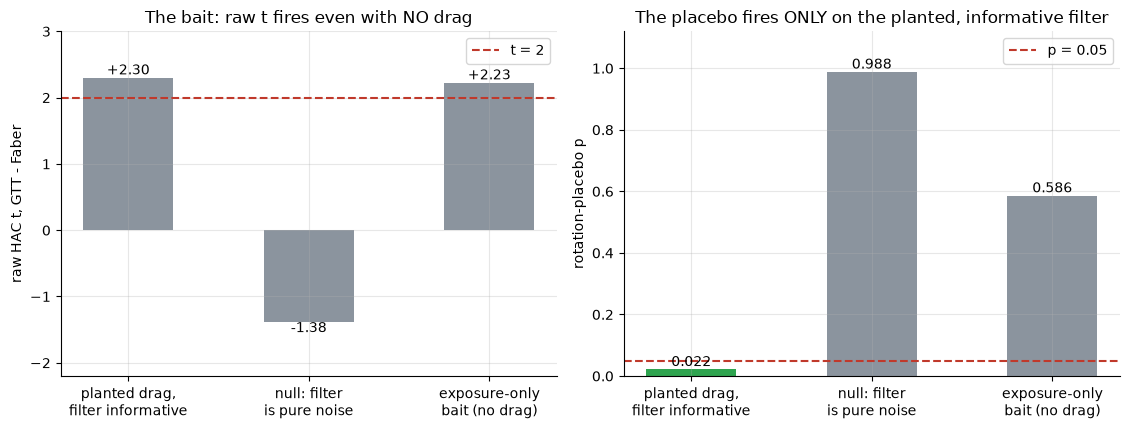

planted drag, filter informative    raw t +2.30   placebo p 0.022
null: filter is pure noise          raw t -1.38   placebo p 0.988
exposure-only bait (no drag)        raw t +2.23   placebo p 0.586


In [6]:
res = []
for gap, linked in ((0.02, True), (0.02, False), (0.0, True)):
    sw = data.synthetic_world(gap=gap, linked=linked, seed=626)
    t = st.run_race(sw, cost_bps=5.0)['t_gtt_vs_faber']['tstat']
    p = st.rotation_placebo(sw, cost_bps=5.0)['p_value']
    res.append((t, p))
labs = [s[0] for s in R['syn']]
# one axis per quantity - never two scales on one chart
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
a1.bar(labs, [r[0] for r in res], color=GREY, width=.5)
a1.axhline(2, ls='--', c=RED, label='t = 2')
for i, r in enumerate(res): a1.annotate(f'{r[0]:+.2f}', (i, r[0]), ha='center', va='bottom' if r[0]>=0 else 'top')
a1.set_ylabel('raw HAC t, GTT - Faber'); a1.set_ylim(-2.2, 3.0); a1.legend()
a1.set_title('The bait: raw t fires even with NO drag')
a2.bar(labs, [r[1] for r in res], color=[GREEN, GREY, GREY], width=.5)
a2.axhline(0.05, ls='--', c=RED, label='p = 0.05')
for i, r in enumerate(res): a2.annotate(f'{r[1]:.3f}', (i, r[1]), ha='center', va='bottom')
a2.set_ylabel('rotation-placebo p'); a2.set_ylim(0, 1.12); a2.legend()
a2.set_title('The placebo fires ONLY on the planted, informative filter')
plt.tight_layout(); plt.show()
for (t, p), lab in zip(res, labs): print(f'{lab.replace(chr(10), " "):35s} raw t {t:+.2f}   placebo p {p:.3f}')

> 💡 In plain words: the middle and right bars are the whole reason this study's inference is trustworthy — a **zero-information** filter can print a raw t above 2 just by adding market exposure, and the rotation placebo correctly calls it nothing (p = 0.586), while the genuinely informative filter is flagged (p = 0.022). *(Machinery proof only — never cited in support of a stamp.)*

## 5 · The verdict

- **Signal `REAL`** — GTT − Faber **+12.26 bps/mo** at HAC **t = +2.32** on 928 months, strengthening with costs (+2.49 at 25 bps), window-robust (6m/12m clear, 24m = 1.96), whipsaw spells −64% with the recession saves intact. Named: current-vintage unemployment (reporting lag modeled, revisions not), price-only leg t = 1.52.
- **Tradability `FRAGILE`** — deployable by anyone at negligible cost, but the edge over buy & hold is uncertified (+4.37 bps/mo, t = +0.61) and the shield is structurally blind to fast, non-recessionary crashes (Nov-1987 max DD; rode COVID fully). A better Faber — still a risk shield, not a return engine.
- **Skill beyond exposure? `MIXED`** — +10.12 of the +12.26 bps/mo is mechanical duty-cycle exposure; the timing residual (+2.15) ranks at **p = 0.0509** against 904 exposure-matched rotations. Certified: *same or better with half the trades*. Not quite: *the filter times recessions*.

## 6 · Going further

- **The construction is the lesson.** Unemployment as a *trigger* failed on this desk ([268-sahm-rule](../../268-sahm-rule/README.md): stocks lead the cycle); unemployment as a *veto on a price signal* works, because a veto only needs the level-question "are we in a deteriorating labor market?", where the series' lag is harmless.
- **Vintage honesty.** We model the reporting lag but use revised data. Near turning points, real-time prints differ from today's series by a tenth or two — enough to move individual switch dates, unlikely to move a 77-year mean, but a genuinely point-in-time test needs ALFRED-style vintages this sandbox doesn't reach.
- **Exposure-matched nulls generalise.** Any "filter X improves overlay Y" claim where X changes the average exposure needs this placebo — the raw active-return t is bait whenever the underlying premium is positive.

*The reproducible core is offline and deterministic; the signal is the 200-day SMA gated by unemployment vs its 12-month SMA; the myth-check is the 904-rotation exposure-matched placebo. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*